# Step 3: Building a Prediction Model

Now, we are going to watch and search for some prediction model, to predict delays. For that we are going to user scikit-learn library.

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import joblib

df = pd.read_csv("cleaned_dataset.csv", sep=";", on_bad_lines="skip")

# Feature engineering temporel
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m")
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["day_of_week"] = df["Date"].dt.dayofweek
df["is_peak_month"] = df["month"].isin([7, 8, 12]).astype(int)
df = df.drop(columns=["Date"])

# Target
target = "Average delay of all trains at arrival"
y = pd.to_numeric(df[target], errors="coerce")

# Feature keep
features = [
    "Departure station",
    "Arrival station",
    "Service",
    "month",
    "year",
    "day_of_week",
    "is_peak_month",
]

X = df[features]

# Encoder les catégorielles
X = pd.get_dummies(X, columns=["Service", "Departure station", "Arrival station"])

# Deleted not finish rows
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

Our model has to be trained and tested. We define the part of the dataset that we going to use for the test, here it's 0.2 so 20% of the data. The other 80% will remain for the training part of our model.

In [2]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

We define our first model (linear regression) to establish a referencement point.

In [3]:
# Modèle
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE : 2.40
MSE  : 14.39
R²   : 0.2208


We obtain 3 differents indicators :
- MAE: mean absolute error (e.g. 1.64 minutes average error).
- MSE: mean squared error (penalizes large errors more).
- R²: between 0 and 1; the closer to 1, the more relevant the model. Here it performs poorly — let's try other models.

In [4]:
# Model
model = MLPRegressor()
model.fit(X_train, y_train)

# Evaluation

y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE : 3.11
MSE  : 18.33
R²   : 0.0075


In [5]:
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Evaluation

y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE : 2.63
MSE  : 21.27
R²   : -0.1517


In [6]:
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

# Evaluation

y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE : 2.38
MSE  : 13.84
R²   : 0.2505


In [7]:
# Model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE : 2.03
MSE  : 11.91
R²   : 0.3550


For the moment, the `RandomForestRegressor` is the more performant with a $R^2$ de 0,31.

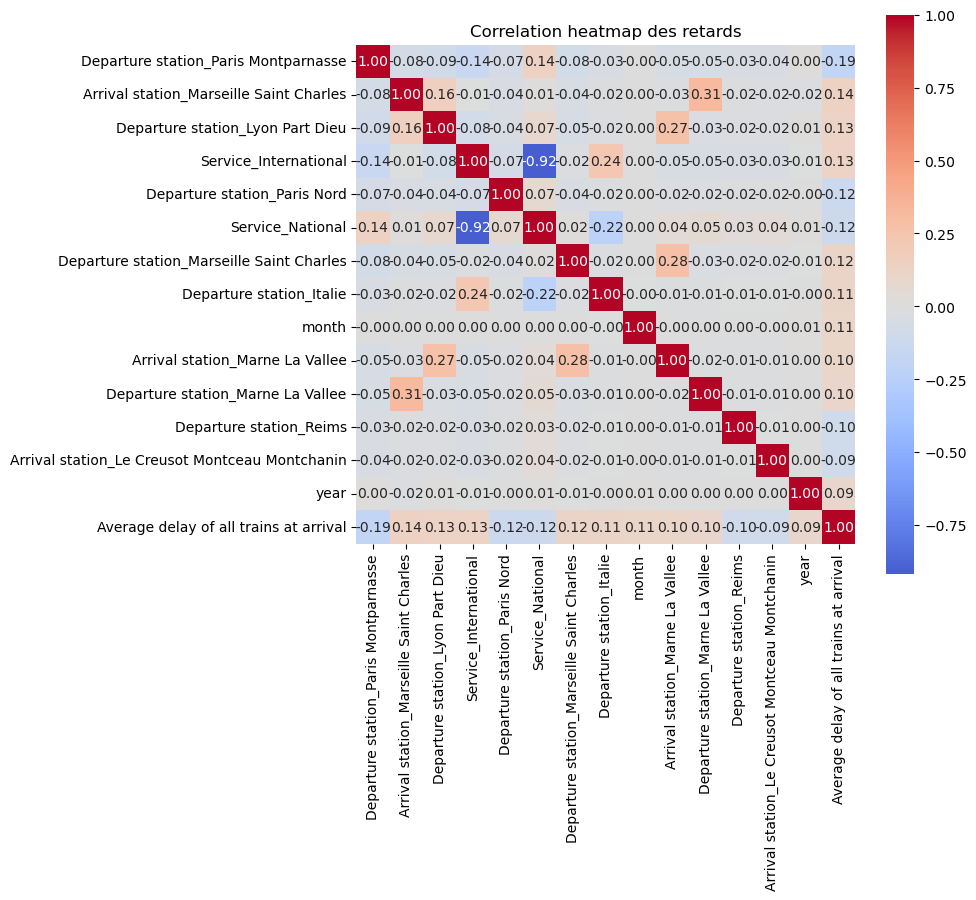

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation sur les features utilisees par le modele
corr_to_target = X.apply(lambda col: col.corr(y, method="spearman"))

# Garder les facteurs les plus corrélés pour une heatmap lisible
top_features = corr_to_target.abs().sort_values(ascending=False).head(14).index

corr_top = pd.concat([X[top_features], y], axis=1).corr(method="spearman")

plt.figure(figsize=(10, 10))
sns.heatmap(
    corr_top,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation heatmap des retards")
plt.tight_layout()
plt.show()

We evaluated our model via scikit-learn library.
Let's switch to XGBoost to create our own model with specific variables, and compare it's result with the best scikit-learn library model.

In [ ]:
import xgboost as xgb
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

df = pd.read_csv("cleaned_dataset.csv", sep=";", on_bad_lines="skip")

# Feature engineering temporel
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m")
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["day_of_week"] = df["Date"].dt.dayofweek
df["is_peak_month"] = df["month"].isin([7, 8, 12]).astype(int)
df = df.drop(columns=["Date"])

# Target
target = "Average delay of all trains at arrival"
y = pd.to_numeric(df[target], errors="coerce")

# Feature
features = [
    "Departure station",
    "Arrival station",
    "Service",
    "month",
    "year",
    "day_of_week",
    "is_peak_month",
]

X = df[features]

# Use library for no number colomns
X = pd.get_dummies(X, columns=["Service", "Departure station", "Arrival station"])

# delete wrong line
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model parametere
model = xgb.XGBRegressor(
    n_estimators=10000, max_depth=8, learning_rate=0.001, random_state=42
)

model.fit(X_train, y_train)

# Print result
y_pred = model.predict(X_test)
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

# Save model
joblib.dump({"model": model, "columns": X.columns.tolist()}, "model.pkl")
print("Model save")

RMSE : 3.54
MAE  : 2.12
R²   : 0.3232
Modèle sauvegardé !


The model is slightly more performant : $R^2 = 0,32$ instead of 0,31 for scikit-learn.

Now, we are using the model to predict the average delay on a specific line.

In [ ]:
import joblib
import pandas as pd

# model load
saved = joblib.load("model.pkl")
model = saved["model"]
model_columns = saved["columns"]

# tmp data for test
data = {
    "month": 12,
    "year": 2028,
    "day_of_week": 0,
    "is_peak_month": 0,
    "Service_National": 1,
    "Departure station_Bordeaux Saint Jean": 1,
    "Arrival station_Paris Montparnasse": 1,
}

X_input = pd.DataFrame([data], columns=model_columns).fillna(0)

prediction = model.predict(X_input)
print(f"Retard prédit : {prediction[0]:.1f} minutes")

Retard prédit : 7.7 minutes


We can also test other prediction, like the odds of cancelation of a train, by changing the input parameter.

In [ ]:
import xgboost as xgb
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

df = pd.read_csv("cleaned_dataset.csv", sep=";", on_bad_lines="skip")

# Feature engineering temporel
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m")
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["day_of_week"] = df["Date"].dt.dayofweek
df["is_peak_month"] = df["month"].isin([7, 8, 12]).astype(int)
df = df.drop(columns=["Date"])

# Target
target = "Number of cancelled trains"
y = pd.to_numeric(df[target], errors="coerce")

# Feature retenue
features = [
    "Departure station",
    "Arrival station",
    "Service",
    "month",
    "year",
    "day_of_week",
    "is_peak_month",
]

X = df[features]

# Use library
X = pd.get_dummies(X, columns=["Service", "Departure station", "Arrival station"])

# Supprimer les lignes incomplètes
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modèle
model = xgb.XGBRegressor(
    n_estimators=10000, max_depth=6, learning_rate=0.001, random_state=42
)

model.fit(X_train, y_train)

# Print result
y_pred = model.predict(X_test)
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

# Save model
joblib.dump(
    {"model": model, "columns": X.columns.tolist()}, "src/Bonus/model_train_cancel.pkl"
)
print("Model save !")

RMSE : 13.80
MAE  : 5.52
R²   : 0.6328
Modèle sauvegardé !


In [ ]:
import joblib
import pandas as pd

# Load model
saved = joblib.load("src/Bonus/model_train_cancel.pkl")
model = saved["model"]
model_columns = saved["columns"]

# data tmp
data = {
    "month": 12,
    "year": 2028,
    "day_of_week": 0,
    "is_peak_month": 0,
    "Service_National": 1,
    "Departure station_Bordeaux Saint Jean": 1,
    "Arrival station_Paris Montparnasse": 1,
}

X_input = pd.DataFrame([data], columns=model_columns).fillna(0)

prediction = model.predict(X_input)
print(f"Probability of a train being canceled : {prediction[0]:.1f} %")

Pourcantage de chance d'un train annulé : 11.0 %


Also a another prediction, like the number of train by month for a specifique line

In [ ]:
import xgboost as xgb
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# import the first csv

df = pd.read_csv("cleaned_dataset.csv", sep=";", on_bad_lines="skip")

# Feature engineering temporel
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m")
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["day_of_week"] = df["Date"].dt.dayofweek
df["is_peak_month"] = df["month"].isin([7, 8, 12]).astype(int)

# target use
target = "Number of scheduled trains"
y = pd.to_numeric(df[target], errors="coerce")

# feature use
features = [
    "year",
    "month",
    "day_of_week",
    "is_peak_month",
    "Departure station",
    "Arrival station",
]
X = df[features]

# Use library for no number categorie
X = pd.get_dummies(X, columns=["Departure station", "Arrival station"])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model parameters
model = xgb.XGBRegressor(
    n_estimators=10000, max_depth=6, learning_rate=0.0001, random_state=42
)

# training line
model.fit(X_train, y_train)

# display result
y_pred = model.predict(X_test)
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

# Save with library
joblib.dump(
    {"model": model, "columns": X.columns.tolist()}, "src/Bonus/model_nb_train.pkl"
)
print("model save")

RMSE : 142.41
MAE  : 114.35
R²   : 0.4128
model save


In [48]:
import joblib
import pandas as pd

# Load model
saved = joblib.load("src/Bonus/model_nb_train.pkl")
model = saved["model"]
model_columns = saved["columns"]

# data test
data = {
    "month": 12,
    "year": 2028,
    "day_of_week": 0,
    "is_peak_month": 0,
    "Departure station_Bordeaux Saint Jean": 1,
    "Arrival station_Paris Montparnasse": 1,
}

X_input = pd.DataFrame([data], columns=model_columns).fillna(0)

prediction = model.predict(X_input)
print(f"Nombre de train estimé ce mois ci : {prediction[0]:.1f}")

Nombre de train estimé ce mois ci : 739.1
